# Take-Home Exercise: Profile It Yourself

**In groups, about 15 to 20 minutes.**

You're given a small script below that does two things:

1. A **tight numeric loop** 
2. A **batch of small repeated calls to a mock database** — the same "N+1 query"
   pattern from Law 1 earlier in the lecture (many small calls instead of one
   bigger one).

Your job:

1. Pick **one software profiler** (reading RAPL directly, or CodeCarbon) and
   **one hardware / socket-level reading** (a lab watt meter if you have one,
   otherwise `nvidia-smi` or `powermetrics` on your own laptop).
2. Run the **unmodified** script under both, and record what each one reports.
3. Apply the **batching fix from Law 1** to the repeated calls, and profile
   again with both tools.
4. Write down: **did the two tools agree on the size of the improvement?** If
   not, what does each one actually cover that the other does not?

**Deliverable:** one paragraph naming which tool you trust more for this
specific workload, and why. Reference what each tool actually covers.

> The point isn't to land on one "correct" number. It's to make any
> disagreement between tools concrete and explainable. If no hardware meter is
> available, using `nvidia-smi`/`powermetrics` on your own laptop, or
> CodeCarbon alone with two different sampling settings, still gives you a
> useful comparison.

## Recap — Why two tools can disagree

Quick recap from the slides, so the comparison later actually means something:

- A **chip-level counter (RAPL)** reads real energy straight off the
  processor and memory. It's accurate for what it covers, but it covers
  *only* the CPU package — not the GPU, disk, network card, or fans, and it's
  usually unavailable on a rented cloud machine.
- A **software estimator (CodeCarbon)** turns CPU/GPU/RAM *usage* into an
  estimated energy number using a model, so it works almost everywhere, but
  it's an estimate, not a direct measurement.
- A **hardware / socket-level meter** (a watt meter, or a laptop's own power
  sensors via `powermetrics`/`nvidia-smi`) measures the whole machine, or the
  whole GPU, from the outside. It will usually report *more* than RAPL alone,
  because it includes everything RAPL doesn't.

None of these is "wrong" — they each answer a slightly different question.
Part of this exercise is noticing that, not just producing a number.

In [1]:
import time
import random
import statistics


## Step 1 — The workload

This is the script you're given: a CPU-bound loop, plus a mock database that
charges a fixed "round trip" cost for every call, regardless if you ask for one
key or many.

In [2]:
def tight_numeric_loop(n=2_000_000):
    """A CPU-bound numeric loop: no I/O, just repeated arithmetic.
    Stands in for 'real work' the script has to do regardless of the
    database pattern used below."""
    total = 0.0
    for i in range(n):
        total += (i * 1.0001) ** 0.5
    return total


class MockDatabase:
    """Pretends to be a slow database sitting on the network. Every call
    pays the same fixed round-trip latency, no matter how much data it
    carries."""

    def __init__(self, latency=0.0008):
        self.latency = latency

    def get_one(self, key):
        time.sleep(self.latency)      # pretend network round trip
        return key * 2

    def get_many(self, keys):
        time.sleep(self.latency)      # ONE round trip for the whole batch
        return [k * 2 for k in keys]


def unbatched_lookup(db, keys):
    """Law-1 'before': one round trip per key (the N+1 pattern)."""
    return [db.get_one(k) for k in keys]


def batched_lookup(db, keys):
    """Law-1 'after': one round trip for all keys."""
    return db.get_many(keys)


def run_workload(lookup_fn, keys, loop_n=2_000_000, latency=0.0008):
    """The full script: the numeric loop, then the database lookups."""
    tight_numeric_loop(loop_n)
    db = MockDatabase(latency=latency)
    return lookup_fn(db, keys)


KEYS = list(range(300))   # how many "rows" the script looks up


## Step 2a — Software profiler, option A: read RAPL directly

This is the same four-step idea from the RAPL slide: read the chip's energy
counter, run the code, read it again, subtract. It only works on Intel/AMD
Linux machines where `/sys/class/powercap/...` is readable — on a laptop
without that access (or on non-Linux machines), it prints a clear message and
returns `None` instead of crashing, so the rest of the notebook should still run.

In [3]:
import contextlib

RAPL_PATH = "/sys/class/powercap/intel-rapl:0/energy_uj"


def read_energy_uj():
    with open(RAPL_PATH) as f:
        return int(f.read())          # microjoules, counts upward


@contextlib.contextmanager
def measure_rapl():
    """Software profiler A: the chip's own RAPL energy counter.
    Yields a dict that gets filled in with `joules` once the `with`
    block finishes. Yields None if RAPL isn't available here."""
    try:
        start = read_energy_uj()
    except (FileNotFoundError, PermissionError) as e:
        print(f"[RAPL] not available on this machine ({e}). "
              "Try this on a lab Linux desktop, or use CodeCarbon below instead.")
        yield None
        return

    result = {}
    yield result
    end = read_energy_uj()
    result["joules"] = (end - start) / 1_000_000


## Step 2b — Software profiler, option B: CodeCarbon

CodeCarbon estimates energy from CPU/GPU/RAM usage, so it works on most
laptops even without RAPL access. Install it once with:

```bash
pip install codecarbon
```

Like `measure_rapl`, this is written to fail gracefully (print a message,
return `None`) if the package isn't installed, so you can run this notebook
even before installing anything.

In [8]:
# uncomment this line to install codecarbon
# %pip install codecarbon  

try:
    from codecarbon import EmissionsTracker
    CODECARBON_AVAILABLE = True
except ImportError:
    CODECARBON_AVAILABLE = False
    print("[CodeCarbon] not installed. Run `pip install codecarbon` and re-run this cell.")


@contextlib.contextmanager
def measure_codecarbon():
    """Software profiler B: CodeCarbon's estimate, in joules, so it's
    directly comparable to the RAPL numbers above (1 kWh = 3,600,000 J).
    Yields None if CodeCarbon isn't installed."""
    if not CODECARBON_AVAILABLE:
        yield None
        return

    tracker = EmissionsTracker(log_level="error", save_to_file=False)
    result = {}
    tracker.start()
    yield result
    tracker.stop()

    # Attribute names have moved around between CodeCarbon versions —
    # `final_emissions_data.energy_consumed` (in kWh) is the current one;
    # if your installed version differs, `print(vars(tracker))` to find it.
    kwh = tracker.final_emissions_data.energy_consumed
    result["joules"] = kwh * 3_600_000


## Step 3 — The hardware / socket-level reading

This one can't be fully automated from inside the notebook the way the two
software profilers above can — a watt meter or `nvidia-smi`/`powermetrics`
needs to run alongside the script, in its own window, so it can sample
continuously while the code runs.

**Note on tool choice:** the workload here is CPU-only (no GPU use), so
`nvidia-smi`'s GPU power draw won't show much. It's the right tool if your
own workload *is* GPU-bound, but for this script a physical watt meter, or
`powermetrics`'s `cpu_power` sampler on a Mac, is the more meaningful pairing.
Always state what you actually measured, per the "Do the two approaches
agree?" slide.

Pick whichever you have available:

```bash
# Lab watt meter: read start/end values off the display, by hand.

# macOS, CPU power specifically:
sudo powermetrics --samplers cpu_power -i 1000 -n 20 > power_log.txt &
# then run the workload cell below, and check power_log.txt afterwards.

# NVIDIA GPU (only meaningful for GPU-bound workloads):
nvidia-smi --query-gpu=power.draw --format=csv -l 1 > gpu_log.csv &
```

Once you have a reading, record it here by hand so it flows into the same
comparison table as the two software profilers:

In [9]:
def record_hardware_reading(label, watts, duration_seconds):
    """Enter what your watt meter / powermetrics / nvidia-smi log showed.
    Converts an average power reading (W) over a known duration (s) into
    joules, the same unit used by the two software profilers above.

    Example: record_hardware_reading("unbatched", watts=10.2, duration_seconds=4.1)
    """
    joules = watts * duration_seconds
    print(f"[hardware:{label}] {watts} W over {duration_seconds} s -> {joules:.2f} J")
    return {"joules": joules}


# Fill these in with your own group's readings once you have them:
hardware_unbatched = None   # e.g. record_hardware_reading("unbatched", watts=..., duration_seconds=...)
hardware_batched = None     # e.g. record_hardware_reading("batched",   watts=..., duration_seconds=...)


## Step 4 — Run the unmodified script under both software tools

This runs `unbatched_lookup` (the "before" version, one round trip per key)
under RAPL and under CodeCarbon, back to back.

In [12]:
results = {}   # collects every reading, so Step 6 can compare them all at once

with measure_rapl() as rapl_before:
    run_workload(unbatched_lookup, KEYS)
results["RAPL / unbatched"] = rapl_before

with measure_codecarbon() as cc_before:
    run_workload(unbatched_lookup, KEYS)
results["CodeCarbon / unbatched"] = cc_before

print(results)


[RAPL] not available on this machine ([Errno 2] No such file or directory: '/sys/class/powercap/intel-rapl:0/energy_uj'). Try this on a lab Linux desktop, or use CodeCarbon below instead.


[codecarbon WARNING @ 21:35:00] Multiple instances of codecarbon are allowed to run at the same time.


{'RAPL / unbatched': None, 'CodeCarbon / unbatched': {'joules': 4.869507587000214}}


## Step 5 — Apply the Law 1 batching fix, and profile again

Same workload, but now the database lookups go through `batched_lookup` —
one round trip for all 300 keys instead of 300 separate ones.

In [13]:
with measure_rapl() as rapl_after:
    run_workload(batched_lookup, KEYS)
results["RAPL / batched"] = rapl_after

with measure_codecarbon() as cc_after:
    run_workload(batched_lookup, KEYS)
results["CodeCarbon / batched"] = cc_after

if hardware_unbatched is not None:
    results["hardware / unbatched"] = hardware_unbatched
if hardware_batched is not None:
    results["hardware / batched"] = hardware_batched

print(results)


[RAPL] not available on this machine ([Errno 2] No such file or directory: '/sys/class/powercap/intel-rapl:0/energy_uj'). Try this on a lab Linux desktop, or use CodeCarbon below instead.
{'RAPL / unbatched': None, 'CodeCarbon / unbatched': {'joules': 4.869507587000214}, 'RAPL / batched': None, 'CodeCarbon / batched': {'joules': 1.8112930799996436}}


## Step 6 — Compare

Build one table with everything that was actually measured (some tools may
be `None` if they weren't available on your machine. That's fine, and worth
noting in your write-up) and the percentage change each one reports.

In [14]:
import pandas as pd

def pct_change(before, after):
    if before is None or after is None or before == 0:
        return None
    return 100 * (after - before) / before


rows = []
for tool in ["RAPL", "CodeCarbon", "hardware"]:
    before = results.get(f"{tool} / unbatched")
    after = results.get(f"{tool} / batched")
    before_j = before["joules"] if before else None
    after_j = after["joules"] if after else None
    rows.append({
        "tool": tool,
        "unbatched (J)": before_j,
        "batched (J)": after_j,
        "change (%)": pct_change(before_j, after_j),
    })

summary = pd.DataFrame(rows)
summary


,tool,unbatched (J),batched (J),change (%)
0,RAPL,NaN,NaN,NaN
1,CodeCarbon,4.869508,1.811293,-62.803363
2,hardware,NaN,NaN,NaN


Now plot whichever tools actually produced numbers on your machine, as
before/after pairs, one small chart per tool (each tool has its own unit
and its own accuracy, so they get their own axes rather than being crammed
onto one shared scale).

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 7.8 MB 6.8 MB/s eta 0:00:01
  Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
     |████████████████████████████████| 2.9 MB 15.7 MB/s eta 0:00:01
     |████████████████████████████████| 249 kB 10.9 MB/s eta 0:00:01
     |████████████████████████████████| 64 kB 5.5 MB/s eta 0:00:01
     |████████████████████████████████| 4.7 MB 11.0 MB/s eta 0:00:01
     |████████████████████████████████| 122 kB 10.6 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


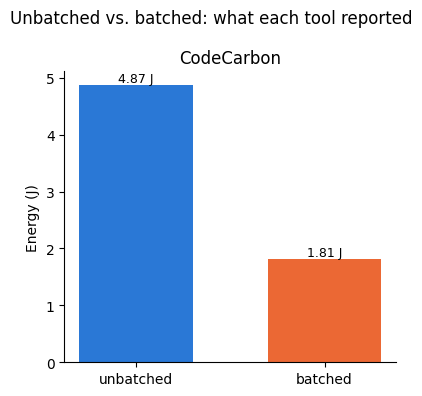

In [ ]:
# %pip install matplotlib

import matplotlib.pyplot as plt

# Fixed categorical colors, consistent across both bars in every panel:
COLOR_BEFORE = "#2a78d6"   # blue  — unbatched
COLOR_AFTER = "#eb6834"    # orange — batched

available = summary.dropna(subset=["unbatched (J)", "batched (J)"])

if available.empty:
    print("No tool produced a reading on this machine — record at least one "
          "(RAPL, CodeCarbon, or a hardware reading) before plotting.")
else:
    fig, axes = plt.subplots(1, len(available), figsize=(4 * len(available), 4), squeeze=False)
    axes = axes[0]

    for ax, (_, row) in zip(axes, available.iterrows()):
        bars = ax.bar(
            ["unbatched", "batched"],
            [row["unbatched (J)"], row["batched (J)"]],
            color=[COLOR_BEFORE, COLOR_AFTER],
            width=0.6,
        )
        ax.set_title(row["tool"])
        ax.set_ylabel("Energy (J)")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        for bar in bars:
            height = bar.get_height()
            ax.annotate(f"{height:.2f} J", (bar.get_x() + bar.get_width() / 2, height),
                        ha="center", va="bottom", fontsize=9)

    fig.suptitle("Unbatched vs. batched: what each tool reported")
    fig.tight_layout()
    plt.show()


## Step 7 — Discuss, then write your deliverable

Discuss these questions as a group before writing anything:

- Did the tools agree on the **size** of the improvement (the "change (%)"
  column above)? If not, by how much did they disagree?
- For each tool, what part of the machine does it actually cover? And what
  does it *not* cover? (Check back against the measurement slides.)
- Would your answer change for a GPU-heavy workload instead of this
  CPU-only one?

**Deliverable** — write one paragraph below naming which tool you trust more
for *this specific workload*, and why, referencing what each tool covers:

In [18]:
deliverable = """
TODO: write your one-paragraph answer here.
"""
print(deliverable)



TODO: write your one-paragraph answer here.

